# 01 — Discovery : FAERS Drug Hospitalization Dataset

**Module :** Machine Learning — Phase 1  
**Auteurs :** Amine El Biyadi / Aya Raissouni / Douae Moeniss  
**Date :** Mai 2026  

---

**Objectif de ce notebook :**  
Charger le dataset FAERS collecté via l'API openFDA, vérifier qu'il respecte toutes les contraintes du projet (taille, types de variables, déséquilibre des classes), et produire une exploration visuelle initiale confirmant que le dataset est exploitable pour la Phase 2.

**Livrables attendus (Section 4 du PDF) :**
- `df.info()` — types et valeurs manquantes
- `df.describe()` — statistiques descriptives
- `df.head()` — aperçu des données
- Vérification du déséquilibre (`value_counts` + graphique)


## 1. Imports et configuration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.family": "DejaVu Sans",
})

PALETTE_MAIN = ["#4C72B0", "#DD8452"]

print("Imports OK")


Imports OK


## 2. Chargement du dataset

In [ ]:
# Try multiple possible paths
possible_paths = [
    "../data/dataset.csv"
]

DATASET_PATH = None
for path in possible_paths:
    if os.path.exists(path):
        DATASET_PATH = path
        print(f"Dataset found at: {path}")
        break

if DATASET_PATH is None:
    raise FileNotFoundError(
        f"Dataset not found in any of these locations: {possible_paths}\n"
        "Please run: python data_collection.py"
    )

df = pd.read_csv(DATASET_PATH)

print(df.shape)
df.head()

Dataset found at: ../data/dataset.csv
(10200, 12)


,patient_age,nb_drugs,nb_reactions,worst_reaction_outcome,nb_suspect_drugs,patient_sex,reporter_qualification,route_of_admin,country,has_black_box_warning,is_concomitant_present,seriousnesshospitalization
0,26.0,1,2,NaN,1,1.0,3.0,41.0,NaN,0,0,0
1,77.0,1,4,NaN,1,2.0,5.0,42.0,NaN,0,0,0
2,NaN,1,2,NaN,1,2.0,5.0,NaN,NaN,0,0,0
3,NaN,1,1,6.0,1,1.0,5.0,NaN,US,0,0,0
4,NaN,9,1,6.0,9,2.0,1.0,NaN,US,0,0,0


## 3. Structure du dataset

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   patient_age                 6775 non-null   float64
 1   nb_drugs                    10200 non-null  int64  
 2   nb_reactions                10200 non-null  int64  
 3   worst_reaction_outcome      9538 non-null   float64
 4   nb_suspect_drugs            10200 non-null  int64  
 5   patient_sex                 10125 non-null  float64
 6   reporter_qualification      9868 non-null   float64
 7   route_of_admin              8014 non-null   float64
 8   country                     9662 non-null   str    
 9   has_black_box_warning       10200 non-null  int64  
 10  is_concomitant_present      10200 non-null  int64  
 11  seriousnesshospitalization  10200 non-null  int64  
dtypes: float64(5), int64(6), str(1)
memory usage: 956.4 KB


## 4. Statistiques descriptives

In [11]:
df.describe(include="all")


,patient_age,nb_drugs,nb_reactions,worst_reaction_outcome,nb_suspect_drugs,patient_sex,reporter_qualification,route_of_admin,country,has_black_box_warning,is_concomitant_present,seriousnesshospitalization
count,6775.000000,10200.000000,10200.000000,9538.00000,10200.000000,10125.000000,9868.000000,8014.000000,9662,10200.0,10200.000000,10200.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,US,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7461,NaN,NaN,NaN
mean,81.390111,3.227353,2.674902,4.91277,1.720980,1.492049,3.496352,49.549414,NaN,0.0,0.351176,0.188333
std,753.776245,3.863310,3.134780,1.76991,1.543115,0.659296,1.697651,8.992182,NaN,0.0,0.477361,0.390997
min,0.000000,1.000000,1.000000,1.00000,1.000000,0.000000,1.000000,2.000000,NaN,0.0,0.000000,0.000000
25%,47.000000,1.000000,1.000000,3.00000,1.000000,1.000000,1.000000,48.000000,NaN,0.0,0.000000,0.000000
50%,61.000000,2.000000,2.000000,6.00000,1.000000,2.000000,4.000000,48.000000,NaN,0.0,0.000000,0.000000
75%,72.000000,4.000000,3.000000,6.00000,2.000000,2.000000,5.000000,48.000000,NaN,0.0,1.000000,0.000000


## 5. Distribution de la cible

seriousnesshospitalization
0    8279
1    1921
Name: count, dtype: int64
seriousnesshospitalization
0    81.166667
1    18.833333
Name: proportion, dtype: float64


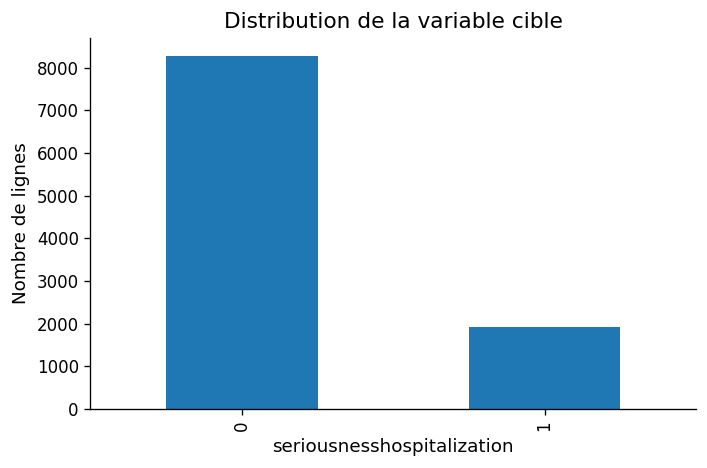

In [12]:
target_col = "seriousnesshospitalization"

counts = df[target_col].value_counts(dropna=False)
ratios = df[target_col].value_counts(normalize=True, dropna=False) * 100

print(counts)
print(ratios)

plt.figure(figsize=(6,4))
counts.plot(kind="bar")
plt.title("Distribution de la variable cible")
plt.ylabel("Nombre de lignes")
plt.tight_layout()
plt.show()
